In [ ]:
# in vivo ROC curves comparing the published mitochondrial mRNA structures from mitoDMS-MaP seq data with PRADA reactivities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from statannot import add_stat_annotation 
from Bio import SeqIO 
from sklearn import metrics 

In [ ]:
## 1. Extend Figure 8a-8b --- --- 
### 1_1. Extend Fig8a --- --- 
### 1_2. Extend Fig8b --- --- 

In [ ]:
### 1_1. Extend Fig8a --- --- 

In [2]:
dir = "./Data/"
vivo = pd.read_csv(dir+'PRADA-MaP_in_vivo_mitochondria_structure_profiles.txt',sep='\t')

vivo_label = vivo[vivo['Modified_effective_depth'] >=5000]
print(vivo.shape)
print(vivo_label.shape)
vivo_label = vivo_label[['Nucleotide','Sequence','Modified_rate']]
vivo_label.columns=['Nucleotide','Sequence','mod_rate']
vivo_label['group'] = 'Label'

vivo_ctrl = vivo[vivo['Untreated_effective_depth'] >=5000]
print(vivo.shape)
print(vivo_ctrl.shape)
vivo_ctrl = vivo_ctrl[['Nucleotide','Sequence','Untreated_rate']]
vivo_ctrl.columns=['Nucleotide','Sequence','mod_rate']
vivo_ctrl['group'] = 'Ctrl'

vivo_flt = pd.concat([vivo_label,vivo_ctrl])
dplot = vivo_flt 

dplot.to_csv('./Data/'+'source_data_Efig8a.csv',sep=',') 

(16569, 29)
(12533, 29)
(16569, 29)
(11855, 29)


G_Label v.s. G_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.384e-32 U_stat=1.380e+06
U_Label v.s. U_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=3.329e-258 U_stat=6.981e+06
A_Label v.s. A_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=4.366e-27 U_stat=7.618e+06
C_Label v.s. C_Ctrl: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=1.459e-213 U_stat=1.133e+07
                mod_rate
Sequence group          
A        Ctrl   0.000086
         Label  0.000107
C        Ctrl   0.000428
         Label  0.000602
G        Ctrl   0.000619
         Label  0.000885
U        Ctrl   0.000345
         Label  0.000732


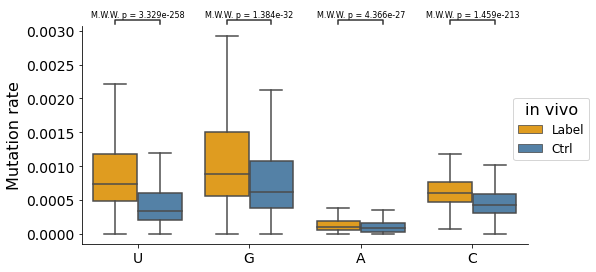

In [3]:
#### plot --- --- 

plt.figure(figsize=(8,4))
order = ['U','G', 'A',  'C']
my_pal = {'Label': "orange", 'Ctrl': "steelblue"}

ax = sns.boxplot(data=dplot, x='Sequence',y='mod_rate', hue='group',showfliers = False,order = order, palette = my_pal)     
plt.title(' ',fontsize = 18)
plt.xlabel('',fontsize = 16) 
plt.ylabel('Mutation rate',fontsize = 16)
plt.xticks(fontsize = 14) 
plt.yticks(fontsize = 14) 
legend=plt.legend(loc='best', title='in vivo',bbox_to_anchor=(1.15, 0.7),prop={'size': 12})
legend.get_title().set_fontsize('16') 
ax.spines[['right', 'top']].set_visible(False) 

add_stat_annotation(ax, data=dplot, x='Sequence',y='mod_rate', hue='group', order=order, 
                    box_pairs = [(("U", 'Label'), ("U", 'Ctrl')),
                                 (("A", 'Label'), ("A", 'Ctrl')),
                                 (("C", 'Label'), ("C", 'Ctrl')),
                                 (("G", 'Label'), ("G", 'Ctrl'))
                                ],
                    test="Mann-Whitney", text_format='full', loc='outside', line_offset_to_box=0.01, verbose=1,fontsize=8)

dir_out = './Data/'
plt.savefig(dir_out+'Extend_Fig8a_vivo_mutrate_label_vs_Ctrl.pdf',bbox_inches='tight', dpi=300) 

print(dplot.groupby(['Sequence','group']).median()[['mod_rate']])  

In [4]:
print(dplot.groupby(['Sequence','group']).mean()[['mod_rate']])  

                mod_rate
Sequence group          
A        Ctrl   0.002024
         Label  0.002101
C        Ctrl   0.003905
         Label  0.003635
G        Ctrl   0.005616
         Label  0.005518
U        Ctrl   0.001287
         Label  0.001541


In [5]:
print(dplot.groupby(["Sequence", "group"]).count())  

                Nucleotide  mod_rate
Sequence group                      
A        Ctrl         3537      3537
         Label        3754      3754
C        Ctrl         3921      3921
         Label        4122      4122
G        Ctrl         1434      1434
         Label        1534      1534
U        Ctrl         2963      2963
         Label        3123      3123


In [ ]:
### 1_2. Extend Fig8b --- --- 

In [6]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

In [7]:
coord = pd.read_csv('./Data/mitochondria_coordinates.csv',sep=',')

In [8]:
def get_AUROC(transcript,dotfile): 

    ### A. input files 

    dir = "./Data/"
    vivo = pd.read_csv(dir+'PRADA-MaP_in_vivo_mitochondria_structure_profiles.txt',sep='\t')
    vivo = vivo[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
    vivo_flt = vivo[vivo['Sequence'] !='N']
    vivo_flt = vivo_flt.reset_index(drop=True)
    vivo_flt['Position'] = vivo_flt.index+1 
    
    ### B. select single gene 

    start = coord.loc[coord['Gene']==transcript, 'Start'].values[0]
    end = coord.loc[coord['Gene']==transcript, 'End'].values[0]
    print(start)
    print(end)
    gene = vivo_flt[(vivo_flt['Position']>=start) & (vivo_flt['Position']<=end)]
    gene['Position2'] = gene['Position'] - start + 1 

    ### C. get the benchmarker 

    dir_bench = './Data/bench/'
    bench = convert_dot(dir_bench+dotfile,transcript)

    ### D. combine data with bench 

    df = pd.merge(gene,bench, how='left',on=['Position2','Position2'])
    df = df[(df['Modified_effective_depth'] >=5000) & (df['Untreated_effective_depth'] >=5000)]
    flt=df[(df['base']=='T') | (df['base']=='U') | (df['base']=='G')]
    print(flt.shape)

    if transcript in ['ND3','ND4L_4','CYTB']: 
        flt = flt[:-2]
        print(flt.shape)
    else:
        flt=flt

    flt['transcript'] = transcript
    flt.to_csv('./Data/'+transcript+'_data_for_plot.csv',sep=',')

    ### E. PLOT AUROC 

    fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
    roc_auc_1 = metrics.auc(fpr_1, tpr_1)
    print(roc_auc_1)

    fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
        ax.tick_params(width = 2)
        
    plt.title('HEK-MTS in vivo \n'+transcript+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
    plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

    plt.legend(loc = 'lower right', fontsize = 18)
    plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate', fontsize = 20)
    plt.xlabel('False Positive Rate', fontsize = 20)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    
    dir_out = './Data/'
    plt.savefig(dir_out+'Extend_Fig8b_'+transcript+'_in_vivo_AUC_reactivity.pdf',bbox_inches='tight', dpi=300)  

5899
7516
(682, 13)
0.7588776202720399


/tmp/ipykernel_27421/2855637335.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_27421/2855637335.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flt['transcript'] = transcript


7585
8268
(267, 13)
0.7885915492957747
9206
9991


/tmp/ipykernel_27421/2855637335.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_27421/2855637335.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flt['transcript'] = transcript
/tmp/ipykernel_27421/2855637335.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

(321, 13)
0.7435786435786437
3304
4262
(309, 13)
0.7186966072736148


...

0.7070446454815639
12336
14147
(636, 13)
0.6016748403812344


/tmp/ipykernel_27421/2855637335.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flt['transcript'] = transcript
/tmp/ipykernel_27421/2855637335.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1
/tmp/ipykernel_27421/2855637335.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

8364
9205
(282, 13)
0.7524828113063408
14746
15888


/tmp/ipykernel_27421/2855637335.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1


(420, 13)
(418, 13)
0.6750520578147966


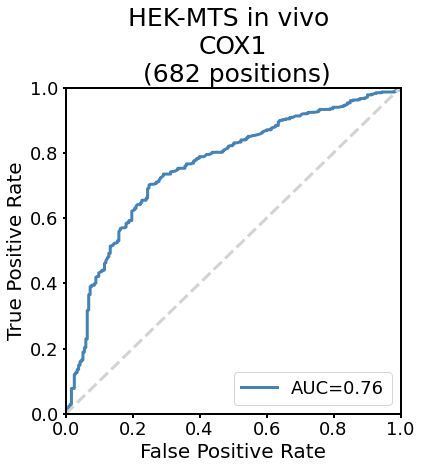

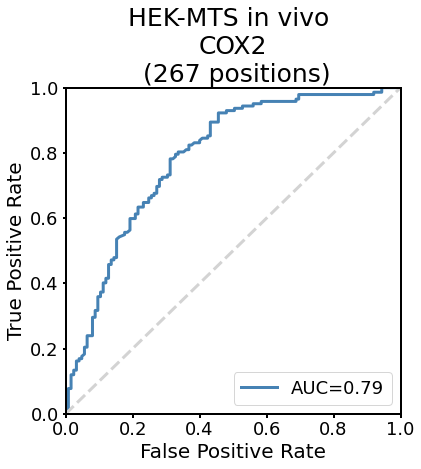

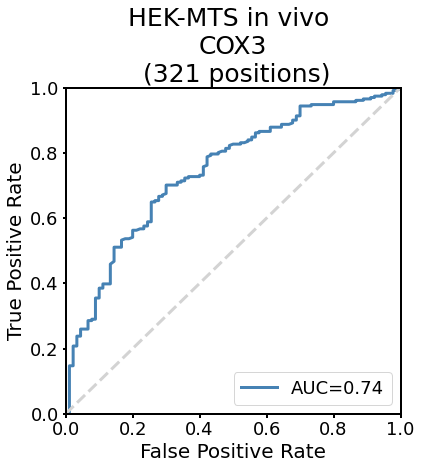

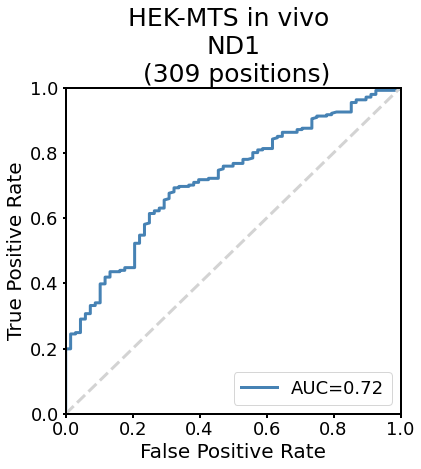

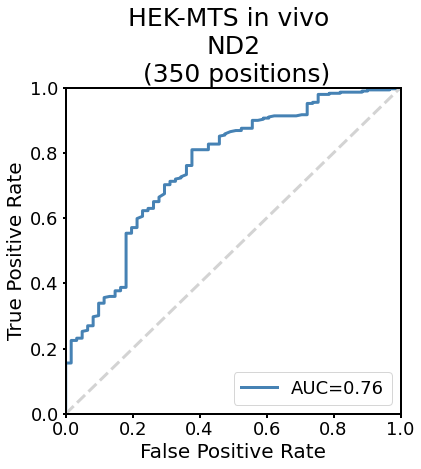

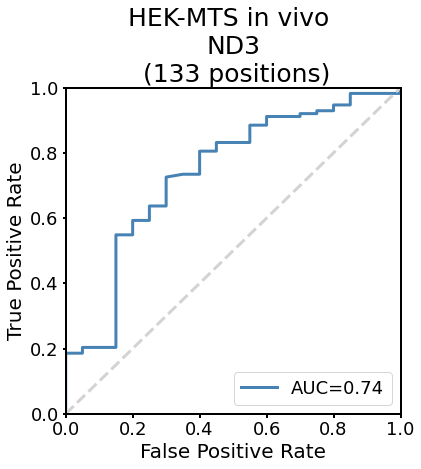

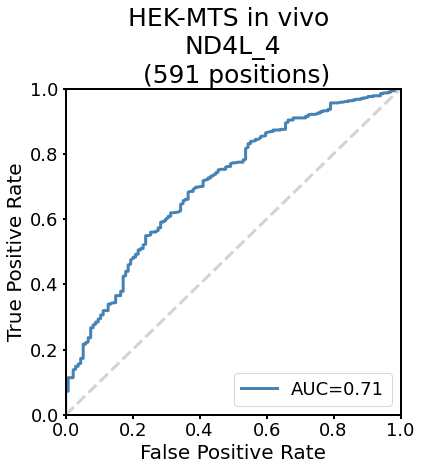

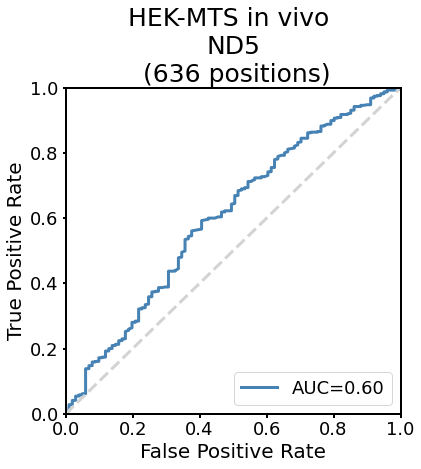

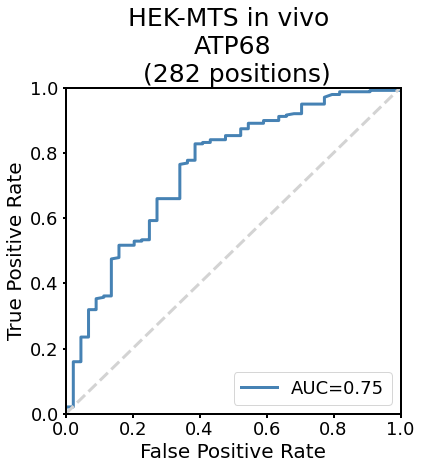

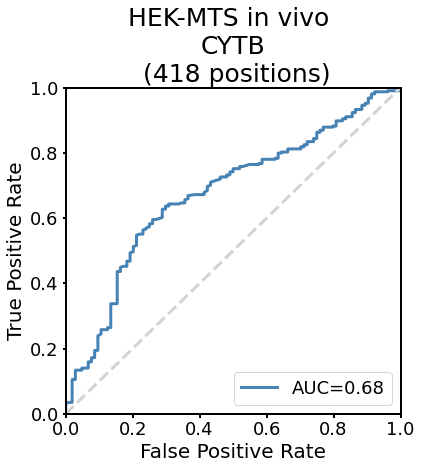

In [9]:
get_AUROC('COX1','bench_positive_COX1_1_1618_162.dot')
get_AUROC('COX2','bench_positive_COX2_1_683_68.dot') 
get_AUROC('COX3','bench_positive_COX3_1_786_79.dot') 
get_AUROC('ND1', 'bench_positive_ND1_1_959_96.dot')  
get_AUROC('ND2', 'bench_positive_ND2_1_1044_104.dot') 

get_AUROC('ND3', 'bench_positive_ND3_1_348_35.dot')
get_AUROC('ND4L_4','bench_positive_ND4_4L_1_1670_167.dot') 
get_AUROC('ND5','bench_positive_ND5_1_1812_181.dot') 
get_AUROC('ATP68','bench_positive_ATP68_1_842_84.dot')
get_AUROC('CYTB','bench_positive_CYTB_1_1143_114.dot')  

In [ ]:
#### test and delete later 

7585
8268
(267, 13)
0.8246539222148979


/tmp/ipykernel_32258/3674599643.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene['Position2'] = gene['Position'] - start + 1


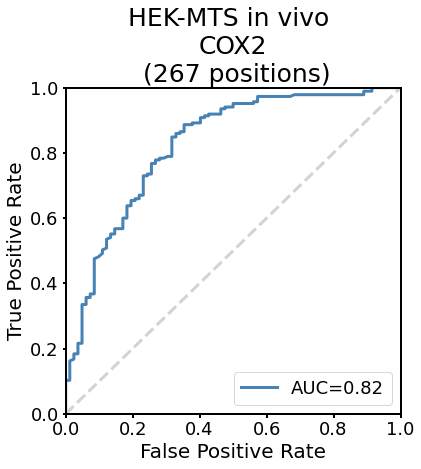

In [8]:
get_AUROC('COX2','WT_positive_COX2_1_708_71_2.dot') 